# Group Assignment 1 - Linear Regression: Housing Prices Prediction
# Group Members: Mai Vy (Valerie) Le, Joel Lane, Seth Mencer


# 1. Data Organization

In [ ]:
# Data Organization
# In this section, we will explore the dataset, handle missing values, and prepare it for analysis.

# Import necessary libraries
import pandas as pd  # Used for data manipulation and analysis
import numpy as np  # Used for numerical operations and handling arrays
import matplotlib.pyplot as plt  # Used for creating static visualizations
import seaborn as sns  # Used for creating visually appealing statistical plots
import scipy.stats as stats  # Used for statistical analysis
import statsmodels.api as sm  # Used for statistical modeling and regression analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif  # Used to detect multicollinearity
from statsmodels.stats.anova import anova_lm  # Used for ANOVA tests

# Install and import the ISLP package (used for model specifications and analysis)
!pip install ISLP
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

# Mount Google Drive
# This step ensures we can access the dataset stored in our Google Drive.
from google.colab import drive
drive.mount('/content/drive')

import os

# Verify the file path
# We list files in our target directory to confirm that the dataset exists.
os.listdir('/content/drive/My Drive/BUS 310: Business Analytics III')

# Define the path to our dataset
file_path = '/content/drive/My Drive/BUS 310: Business Analytics III/Group Assignment 1/housing_price_full_sample.csv'

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display all columns
# This ensures that all columns in the dataset are visible when we preview the DataFrame.
pd.set_option('display.max_columns', None)

# Preview the dataset
# Display the first few rows to confirm that the dataset was loaded correctly.
df.head()

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 856.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.3/819.3 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Print the total number of columns in the dataset
# This helps us verify if all columns were loaded correctly and check if any transformations (like dummy variables) increased the column count.
print(len(df.columns))

81


# 1.1.	Missing data and imputing missing data

In [ ]:
# Check for missing values in the dataset
# We identify which columns have missing values and how many are missing in each.
missing_values = df.isnull().sum()

# Filter only the columns that contain missing values
# This ensures we focus only on the variables that need imputation.
missing_values = missing_values[missing_values > 0]

# Display the columns with missing values
# This helps us determine the extent of missing data before applying any fixes.
print(missing_values)

MSZoning           4
LotFrontage      486
Alley           2721
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType      1766
MasVnrArea        23
BsmtQual          81
BsmtCond          82
BsmtExposure      82
BsmtFinType1      79
BsmtFinSF1         1
BsmtFinType2      80
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
Electrical         1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu     1420
GarageType       157
GarageYrBlt      159
GarageFinish     159
GarageCars         1
GarageArea         1
GarageQual       159
GarageCond       159
PoolQC          2909
Fence           2348
MiscFeature     2814
SaleType           1
dtype: int64


In [ ]:
# Impute missing values to handle incomplete data and ensure consistency
from sklearn.impute import SimpleImputer

# Identify numerical columns in the dataset
num_cols = df.select_dtypes(include=['number']).columns

# Use the mean strategy to impute missing numerical values
# This replaces missing values with the column's average, helping maintain the overall data distribution.
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Identify categorical columns in the dataset
cat_cols = df.select_dtypes(exclude=['number']).columns

# Use the most frequent strategy to impute missing categorical values
# This fills missing values with the most common category in each column, preserving data consistency.
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Verify that our dataset no longer contains missing values
# This step ensures that all missing values have been successfully handled.
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64


# 1.2. Label encoding/factorizing the remaining character variables

In [ ]:
# Convert categorical variables into a list for processing
cat_vars = cat_cols.tolist()

# Create dummy variables for categorical columns
# This process converts categorical variables into numerical format by creating separate binary columns (0 or 1) for each unique category.
# We use drop_first=True to avoid the dummy variable trap and reduce redundancy.
df_dummies = pd.get_dummies(df[cat_cols], drop_first=True)

# Display the first few rows of the newly created dummy variable dataset
df_dummies.head()

,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,Fal

# 1.3. Changing some numeric variables into categorical variables

Check how many years of data do we have

In [ ]:
# Count the number of unique years in which houses were sold
# This helps us understand the range of years covered in our dataset.
unique_years_count = df['YrSold'].nunique()

# Print the total number of unique years in the dataset
print(f'Number of unique years: {unique_years_count}')

Number of unique years: 5


Convert year and month sold, year built, and MSSubClass from numeric variables into dummy variables.

In [ ]:
# Identify columns related to time that should be treated as categorical variables
# These variables represent categorical time-related features rather than continuous numerical values.
categorical_time_cols = ['MSSubClass', 'YrSold', 'MoSold', 'YearBuilt']

# Convert these categorical time-related variables into dummy variables
# This helps us prepare them for analysis by creating binary indicator variables.
df_time_dummies = pd.get_dummies(df[categorical_time_cols], columns=categorical_time_cols, drop_first=True)

# Display the first few rows of the transformed dataset
df_time_dummies.head()

,MSSubClass_30.0,MSSubClass_40.0,MSSubClass_45.0,MSSubClass_50.0,MSSubClass_60.0,MSSubClass_70.0,MSSubClass_75.0,MSSubClass_80.0,MSSubClass_85.0,MSSubClass_90.0,MSSubClass_120.0,MSSubClass_150.0,MSSubClass_160.0,MSSubClass_180.0,MSSubClass_190.0,YrSold_2007.0,YrSold_2008.0,YrSold_2009.0,YrSold_2010.0,MoSold_2.0,MoSold_3.0,MoSold_4.0,MoSold_5.0,MoSold_6.0,MoSold_7.0,MoSold_8.0,MoSold_9.0,MoSold_10.0,MoSold_11.0,MoSold_12.0,YearBuilt_1875.0,YearBuilt_1879.0,YearBuilt_1880.0,YearBuilt_1882.0,YearBuilt_1885.0,YearBuilt_1890.0,YearBuilt_1892.0,YearBuilt_1893.0,YearBuilt_1895.0,YearBuilt_1896.0,YearBuilt_1898.0,YearBuilt_1900.0,YearBuilt_1901.0,YearBuilt_1902.0,YearBuilt_1904.0,YearBuilt_1905.0,YearBuilt_1906.0,YearBuilt_1907.0,YearBuilt_1908.0,YearBuilt_1910.0,YearBuilt_1911.0,YearBuilt_1912.0,YearBuilt_1913.0,YearBuilt_1914.0,YearBuilt_1915.0,YearBuilt_1916.0,YearBuilt_1917.0,YearBuilt_1918.0,YearBuilt_1919.0,YearBuilt_1920.0,YearBuilt_1921.0,YearBuilt_1922.0,YearBuilt_1923.0,YearBuilt_1924.0,YearBuilt_1925.0,YearBuilt_1926.0,YearBuilt_1927.0,YearBuilt_1928.0,YearBuilt_1929.0,YearBuilt_1930.0,YearBuilt_1931.0,YearBuilt_1932.0,YearBuilt_1934.0,YearBuilt_1935.0,YearBuilt_1936.0,YearBuilt_1937.0,YearBuilt_1938.0,YearBuilt_1939.0,YearBuilt_1940.0,YearBuilt_1941.0,YearBuilt_1942.0,YearBuilt_1945.0,YearBuilt_1946.0,YearBuilt_1947.0,YearBuilt_1948.0,YearBuilt_1949.0,YearBuilt_1950.0,YearBuilt_1951.0,YearBuilt_1952.0,YearBuilt_1953.0,YearBuilt_1954.0,YearBuilt_1955.0,YearBuilt_1956.0,YearBuilt_1957.0,YearBuilt_1958.0,YearBuilt_1959.0,YearBuilt_1960.0,YearBuilt_1961.0,YearBuilt_1962.0,YearBuilt_1963.0,YearBuilt_1964.0,YearBuilt_1965.0,YearBuilt_1966.0,YearBuilt_1967.0,YearBuilt_1968.0,YearBuilt_1969.0,YearBuilt_1970.0,YearBuilt_1971.0,YearBuilt_1972.0,YearBuilt_1973.0,YearBuilt_1974.0,YearBuilt_1975.0,YearBuilt_1976.0,YearBuilt_1977.0,YearBuilt_1978.0,YearBuilt_1979.0,YearBuilt_1980.0,YearBuilt_1981.0,YearBuilt_1982.0,YearBuilt_1983.0,YearBuilt_1984.0,YearBuilt_1985.0,YearBuilt_1986.0,YearBuilt_1987.0,YearBuilt_1988.0,YearBuilt_1989.0,YearBuilt_1990.0,YearBuilt_1991.0,YearBuilt_1992.0,YearBuilt_1993.0,YearBuilt_1994.0,YearBuilt_1995.0,YearBuilt_1996.0,YearBuilt_1997.0,YearBuilt_1998.0,YearBuilt_1999.0,YearBuilt_2000.0,YearBuilt_2001.0,YearBuilt_2002.0,YearBuilt_2003.0,YearBuilt_2004.0,YearBuilt_2005.0,YearBuilt_2006.0,YearBuilt_2007.0,YearBuilt_2008.0,YearBuilt_2009.0,YearBuilt_2010.0
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,Fals

In [ ]:
# Combine the original dataset with the newly created dummy variables
# - `df`: Original dataset
# - `df_dummies`: Dummy variables created from categorical columns
# - `df_time_dummies`: Dummy variables for time-related categorical variables (Year, Month, etc.)
df_final = pd.concat([df, df_dummies, df_time_dummies], axis=1)

# Display the first few rows to confirm successful concatenation
df_final.head()

# Create a refined dataset containing only numerical and dummy variables
# - Drop categorical columns (`cat_cols`) since they have been converted into dummies
# - Drop categorical time-related variables (`categorical_time_cols`) after encoding
df_final_num_dummies = df_final.drop(cat_cols, axis=1)
df_final_num_dummies = df_final_num_dummies.drop(categorical_time_cols, axis=1)

# Display the first few rows of the final numerical dataset
df_final_num_dummies.head()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,SalePrice,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,MSSubClass_30.0,MSSubClass_40.0,MSSubClass_45.0,MSSubClass_50.0,MSSubClass_60.0,MSSubClass_70.0,MSSubClass_75.0,MSSubClass_80.0,MSSubClass_85.0,MSSubClass_90.0,MSSubClass_120.0,MSSubClass_150.0

# 2. Exploring important variables

# 2.2. Exploring important variables

Check the basic descriptive statistics for SalePrice

In [ ]:
# Generate descriptive statistics for the SalePrice variable
# This provides key insights such as mean, median, min, max, and quartiles.
sales_price_stats = df['SalePrice'].describe().round(2)

# Print the summary statistics of SalePrice
print(sales_price_stats)

count      2919.00
mean     180052.86
std       57381.56
min       34900.00
25%      154795.00
50%      176735.00
75%      191896.00
max      755000.00
Name: SalePrice, dtype: float64


Box plot that show the distribution of SalePrice

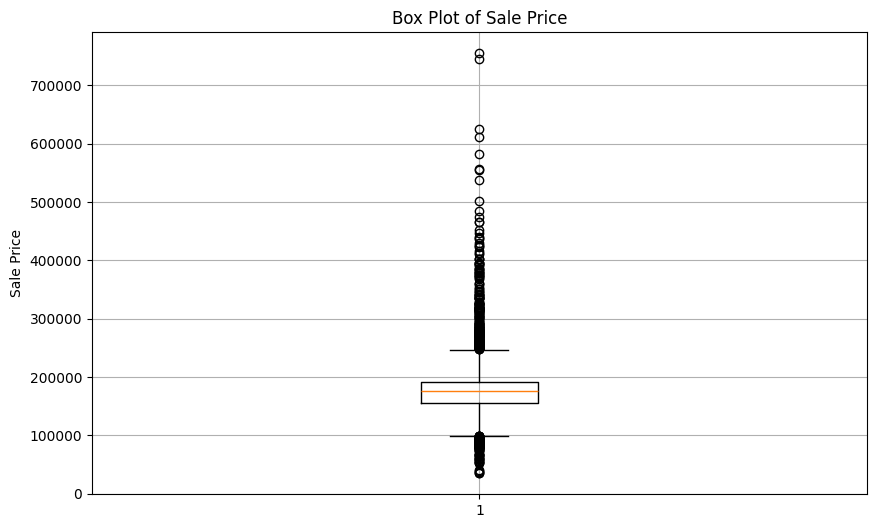

In [ ]:
# Create a box plot to visualize the distribution of SalePrice
# This helps us identify the spread of home prices and detect potential outliers.

plt.figure(figsize=(10, 6))  # Set figure size for better visibility
plt.boxplot(df['SalePrice'])  # Generate the box plot for SalePrice

# Add title and labels
plt.title('Box Plot of Sale Price')
plt.ylabel('Sale Price')

# Enable grid for easier interpretation of price distribution
plt.grid()

# Display the plot
plt.show()

# Histogram of SalePrice

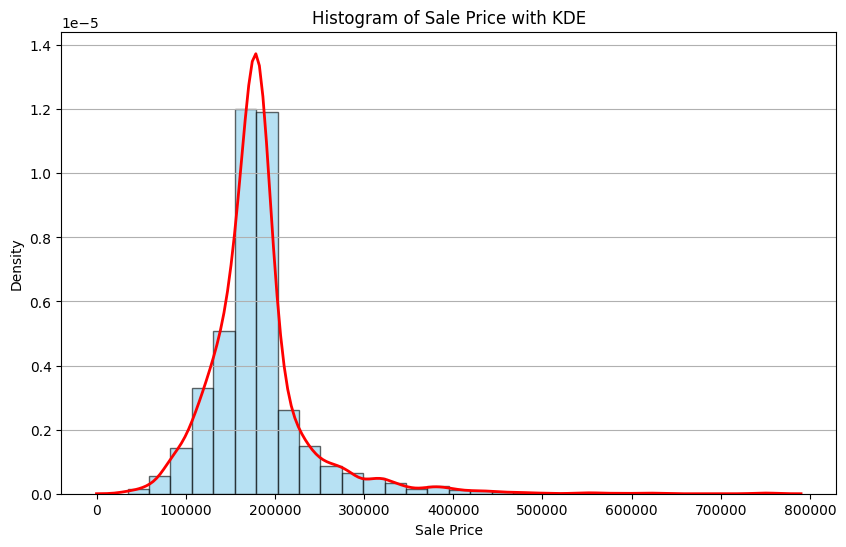

In [ ]:
# Create a histogram to visualize the distribution of SalePrice
# This helps us understand the frequency of different price ranges in the dataset.

plt.figure(figsize=(10, 6))  # Set figure size for better readability

# Generate the histogram
# - bins=30: Groups prices into 30 bins for better granularity
# - density=True: Normalizes the histogram to show probabilities instead of counts
# - color='skyblue': Sets bar color
# - edgecolor='black': Adds borders to bars for clarity
# - alpha=0.6: Adjusts transparency for better visibility
count, bins, ignored = plt.hist(df['SalePrice'], bins=30, density=True,
                                color='skyblue', edgecolor='black', alpha=0.6)

# Add a Kernel Density Estimate (KDE) line to show the smooth distribution of SalePrice
sns.kdeplot(df['SalePrice'], color='red', lw=2)

# Add title and labels
plt.title('Histogram of Sale Price with KDE')
plt.xlabel('Sale Price')
plt.ylabel('Density')

# Add a grid for better readability
plt.grid(axis='y')

# Display the plot
plt.show()

# Important numerical predictors

Checking how many numerical variables are in the data set

In [ ]:
# Identify numerical variables in the dataset
# - `df_final_num_dummies`: Dataset containing only numerical and dummy variables
# - `num_vars`: Stores the list of numerical variable names
num_vars = df_final_num_dummies.select_dtypes(include=['number']).columns

# Display the total count of numerical variables in the dataset
print(f'Total numerical variables: {len(num_vars)}')

Total numerical variables: 34


Sorted Correlations between each numerical predictor and SalePrice

In [ ]:
# Select only numerical columns from the dataset
# This ensures we analyze only relevant numerical features when computing correlations.
numeric_df = df_final.select_dtypes(include=['number'])

# Compute the correlation between each numerical variable and SalePrice
# - `corr()['SalePrice']`: Extracts the correlation of all numerical features with SalePrice
# - `drop('SalePrice')`: Excludes SalePrice itself from the results
# - `sort_values(ascending=False)`: Sorts the correlations in descending order to identify the strongest predictors
correlations = numeric_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

# Print the correlation values to understand which features are most strongly related to SalePrice
print("All correlation values with SalePrice:")
print(correlations)

All correlation values with SalePrice:
GrLivArea        0.588010
OverallQual      0.550911
TotRmsAbvGrd     0.469800
GarageCars       0.469249
GarageArea       0.464809
1stFlrSF         0.462865
TotalBsmtSF      0.453212
FullBath         0.433711
YearBuilt        0.362066
MasVnrArea       0.353953
Fireplaces       0.353567
YearRemodAdd     0.350032
GarageYrBlt      0.314918
LotFrontage      0.302018
LotArea          0.296496
BsmtFinSF1       0.272195
2ndFlrSF         0.272140
WoodDeckSF       0.238381
OpenPorchSF      0.236376
BedroomAbvGr     0.229611
HalfBath         0.228836
BsmtUnfSF        0.175191
BsmtFullBath     0.148126
ScreenPorch      0.082308
PoolArea         0.081039
MoSold           0.067222
3SsnPorch        0.029979
MiscVal         -0.000037
BsmtFinSF2      -0.007437
Id              -0.011630
BsmtHalfBath    -0.012616
LowQualFinSF    -0.015395
YrSold          -0.039064
OverallCond     -0.065785
EnclosedPorch   -0.070698
KitchenAbvGr    -0.071760
MSSubClass      -0.087910

Compute the correlation matrix for all numerical variables

In [ ]:
# Extract the top 10 numerical features that have the strongest correlation with SalePrice
# These variables will be the most important predictors in our analysis.
top_10_corr = correlations.head(10)

# Print the top 10 correlations to identify key features influencing SalePrice
print("Top 10 features most correlated with SalePrice:")
print(top_10_corr)

Top 10 features most correlated with SalePrice:
GrLivArea       0.588010
OverallQual     0.550911
TotRmsAbvGrd    0.469800
GarageCars      0.469249
GarageArea      0.464809
1stFlrSF        0.462865
TotalBsmtSF     0.453212
FullBath        0.433711
YearBuilt       0.362066
MasVnrArea      0.353953
Name: SalePrice, dtype: float64


Heatmap of the correlation pairs for the top 10 variables that has the highest correlation with SalePrice

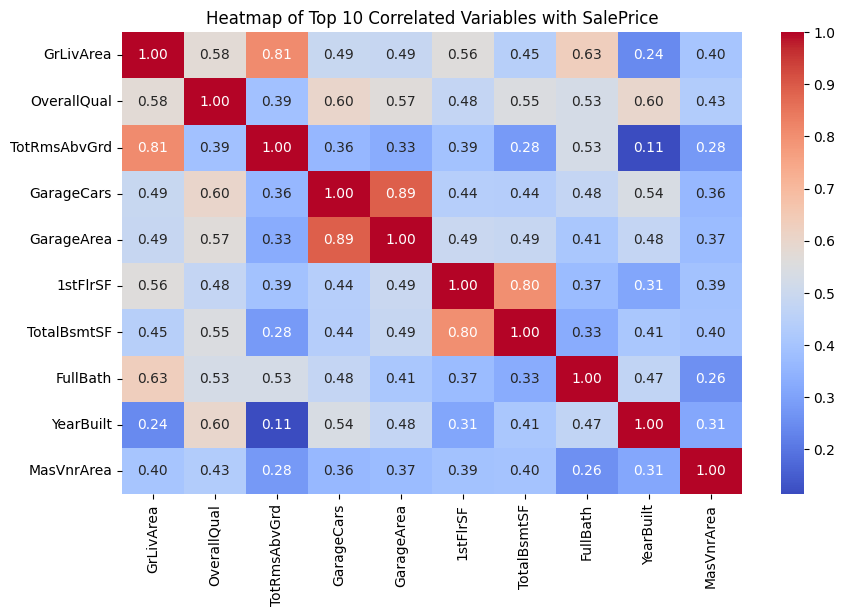

In [ ]:
# Set figure size for better readability
plt.figure(figsize=(10, 6))

# Create a heatmap to visualize correlations among the top 10 variables
# - `df_final[top_10_corr.index]`: Selects only the top 10 correlated features
# - `.corr()`: Computes the correlation matrix between these features
# - `annot=True`: Displays correlation values inside the heatmap
# - `cmap='coolwarm'`: Uses a color gradient for better visualization
# - `fmt='.2f'`: Formats numbers to 2 decimal places for clarity
sns.heatmap(df_final[top_10_corr.index].corr(), annot=True, cmap='coolwarm', fmt='.2f')

# Add a title for context
plt.title('Heatmap of Top 10 Correlated Variables with SalePrice')

# Display the heatmap
plt.show()

Box plot of the Overall Quality on SalePrice

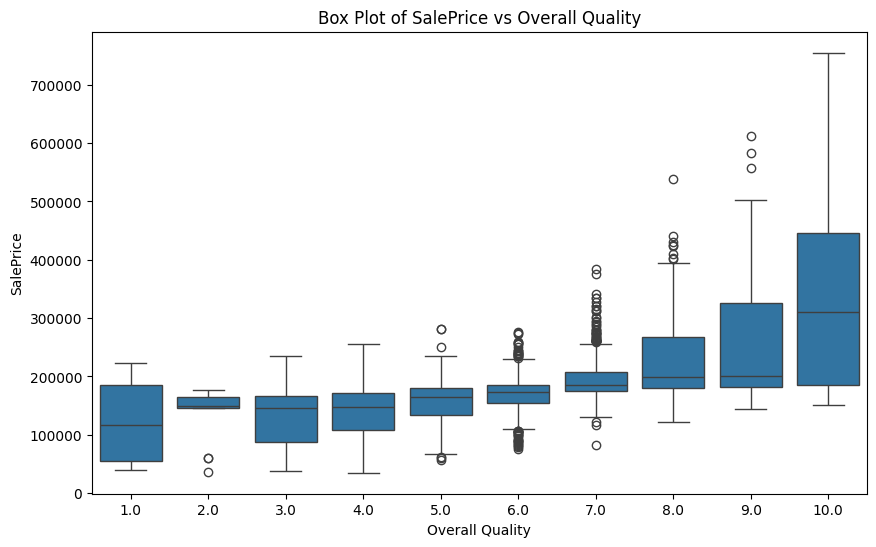

In [ ]:
# Create a boxplot to examine the relationship between Overall Quality and SalePrice
# This helps us understand how home quality impacts sale prices.

plt.figure(figsize=(10, 6))  # Set figure size for better readability

# Generate a box plot with Overall Quality on the X-axis and SalePrice on the Y-axis
sns.boxplot(x='OverallQual', y='SalePrice', data=df)

# Add title and axis labels for clarity
plt.title('Box Plot of SalePrice vs Overall Quality')
plt.xlabel('Overall Quality')  # Represents the rated quality of the home
plt.ylabel('SalePrice')  # Represents the home's selling price

# Display the plot
plt.show()

Scatter plot between GrLivArea and SalePrice with a linear regression line

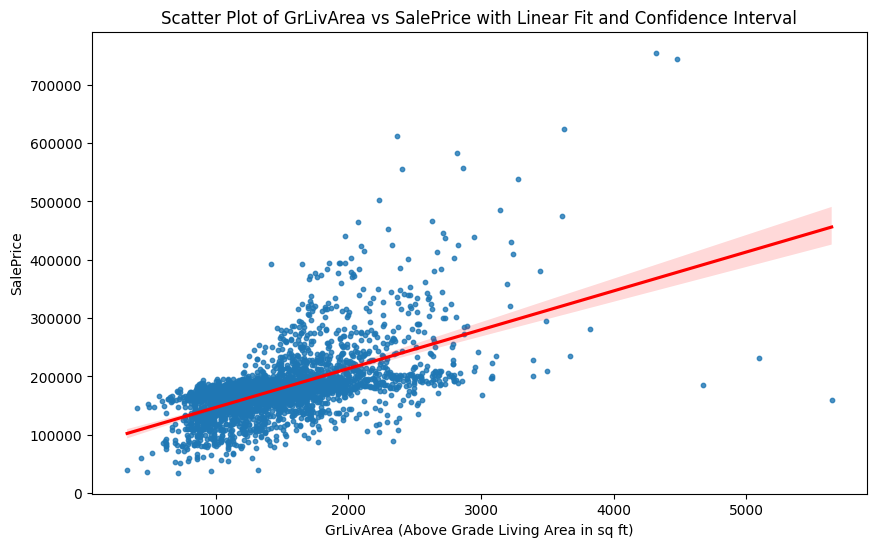

In [ ]:
# Create a scatter plot to examine the relationship between GrLivArea (above-grade living area) and SalePrice
# This helps us identify trends and potential outliers in how home size affects sale prices.

plt.figure(figsize=(10, 6))  # Set figure size for better readability

# Generate a scatter plot with a linear regression line
# - ci=95: Adds a 95% confidence interval around the regression line
# - scatter_kws={'s':10}: Adjusts point size for better visibility
# - line_kws={'color':'red'}: Makes the regression line red for clear distinction
sns.regplot(x='GrLivArea', y='SalePrice', data=df, ci=95, scatter_kws={'s':10}, line_kws={'color':'red'})

# Add title and axis labels for clarity
plt.title('Scatter Plot of GrLivArea vs SalePrice with Linear Fit and Confidence Interval')
plt.xlabel('GrLivArea (Above Grade Living Area in sq ft)')
plt.ylabel('SalePrice')

# Display the plot
plt.show()

# Important categorical predictors

Bar charts of the average SalePrice for and the number of sales for year sold

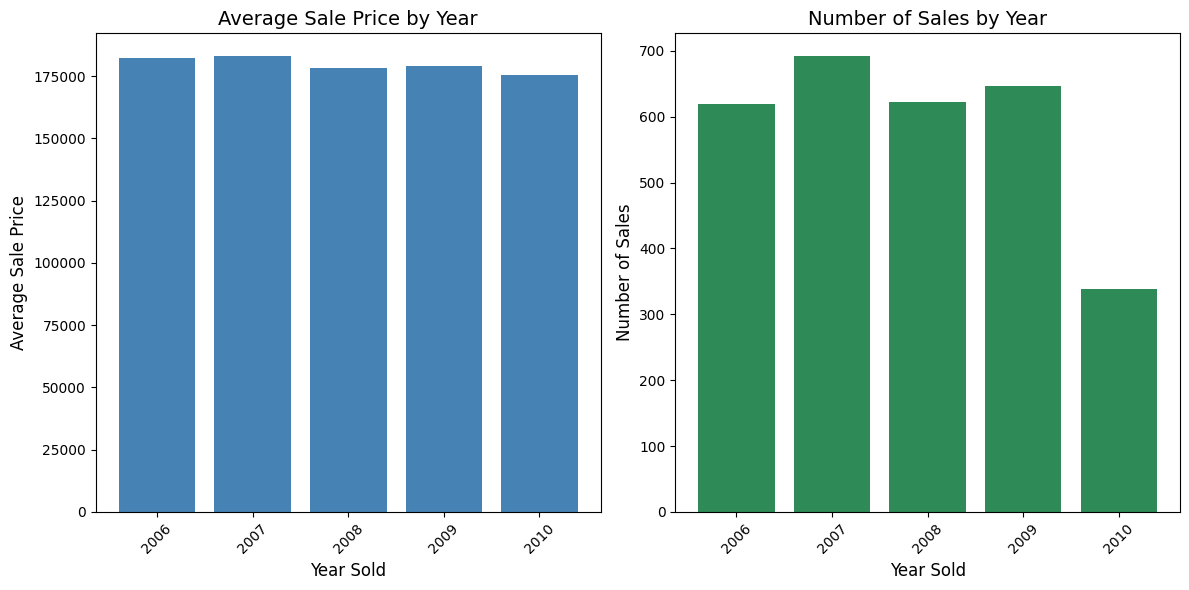

In [ ]:
# Calculate the average SalePrice for each year sold
# This helps us understand price trends over the years
mean_sale_price = df.groupby('YrSold')['SalePrice'].mean().reset_index()

# Calculate the number of observations (total houses sold) for each year
# This helps analyze the volume of transactions over time
count_observations = df.groupby('YrSold').size().reset_index(name='Count')

# Create a figure with 2 subplots (side-by-side) for better visualization
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First subplot: Bar chart showing the average Sale Price by Year Sold
axs[0].bar(mean_sale_price['YrSold'], mean_sale_price['SalePrice'], color='#4682B4')  # Steel Blue
axs[0].set_title('Average Sale Price by Year', fontsize=14)  # Add title
axs[0].set_xlabel('Year Sold', fontsize=12)  # Label for x-axis
axs[0].set_ylabel('Average Sale Price', fontsize=12)  # Label for y-axis
axs[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Second subplot: Bar chart showing the number of sales per year
axs[1].bar(count_observations['YrSold'], count_observations['Count'], color='#2E8B57')  # Sea Green
axs[1].set_title('Number of Sales by Year', fontsize=14)  # Add title
axs[1].set_xlabel('Year Sold', fontsize=12)  # Label for x-axis
axs[1].set_ylabel('Number of Sales', fontsize=12)  # Label for y-axis
axs[1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plots
plt.show()

Bar charts that show the average SalePrice for and the number of sales for month sold

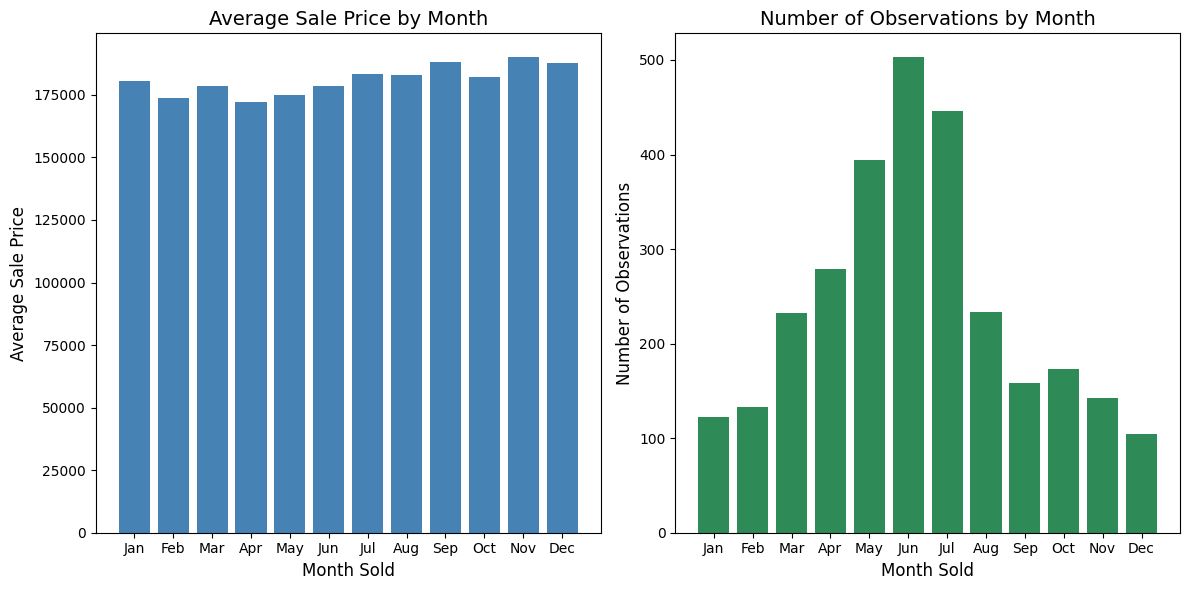

In [ ]:
# Calculate the average SalePrice for each month
# This helps us understand seasonal price trends in home sales
df_original = df.copy()

mean_sale_price = df_original.groupby('MoSold')['SalePrice'].mean().reset_index()

# Calculate the number of observations (total houses sold) for each month
# This helps identify peak and low sales months
count_observations = df_original.groupby('MoSold').size().reset_index(name='Count')

# Create a figure with two subplots (side by side) for comparison
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart for the average Sale Price by month
axs[0].bar(mean_sale_price['MoSold'], mean_sale_price['SalePrice'], color='#4682B4')  # Steel blue color
axs[0].set_title('Average Sale Price by Month', fontsize=14)  # Title for the first plot
axs[0].set_xlabel('Month Sold', fontsize=12)  # X-axis label
axs[0].set_ylabel('Average Sale Price', fontsize=12)  # Y-axis label
axs[0].set_xticks(range(1, 13))  # Ensure x-axis represents all 12 months
axs[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])  # Convert to month names for readability

# Bar chart for the number of sales per month
axs[1].bar(count_observations['MoSold'], count_observations['Count'], color='#2E8B57')  # Sea green color
axs[1].set_title('Number of Observations by Month', fontsize=14)  # Title for the second plot
axs[1].set_xlabel('Month Sold', fontsize=12)  # X-axis label
axs[1].set_ylabel('Number of Observations', fontsize=12)  # Y-axis label
axs[1].set_xticks(range(1, 13))  # Ensure x-axis represents all 12 months
axs[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])  # Convert to month names for better readability

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plots
plt.show()

Bar chart that show the median SalePrice and number of sales by Neighorhood

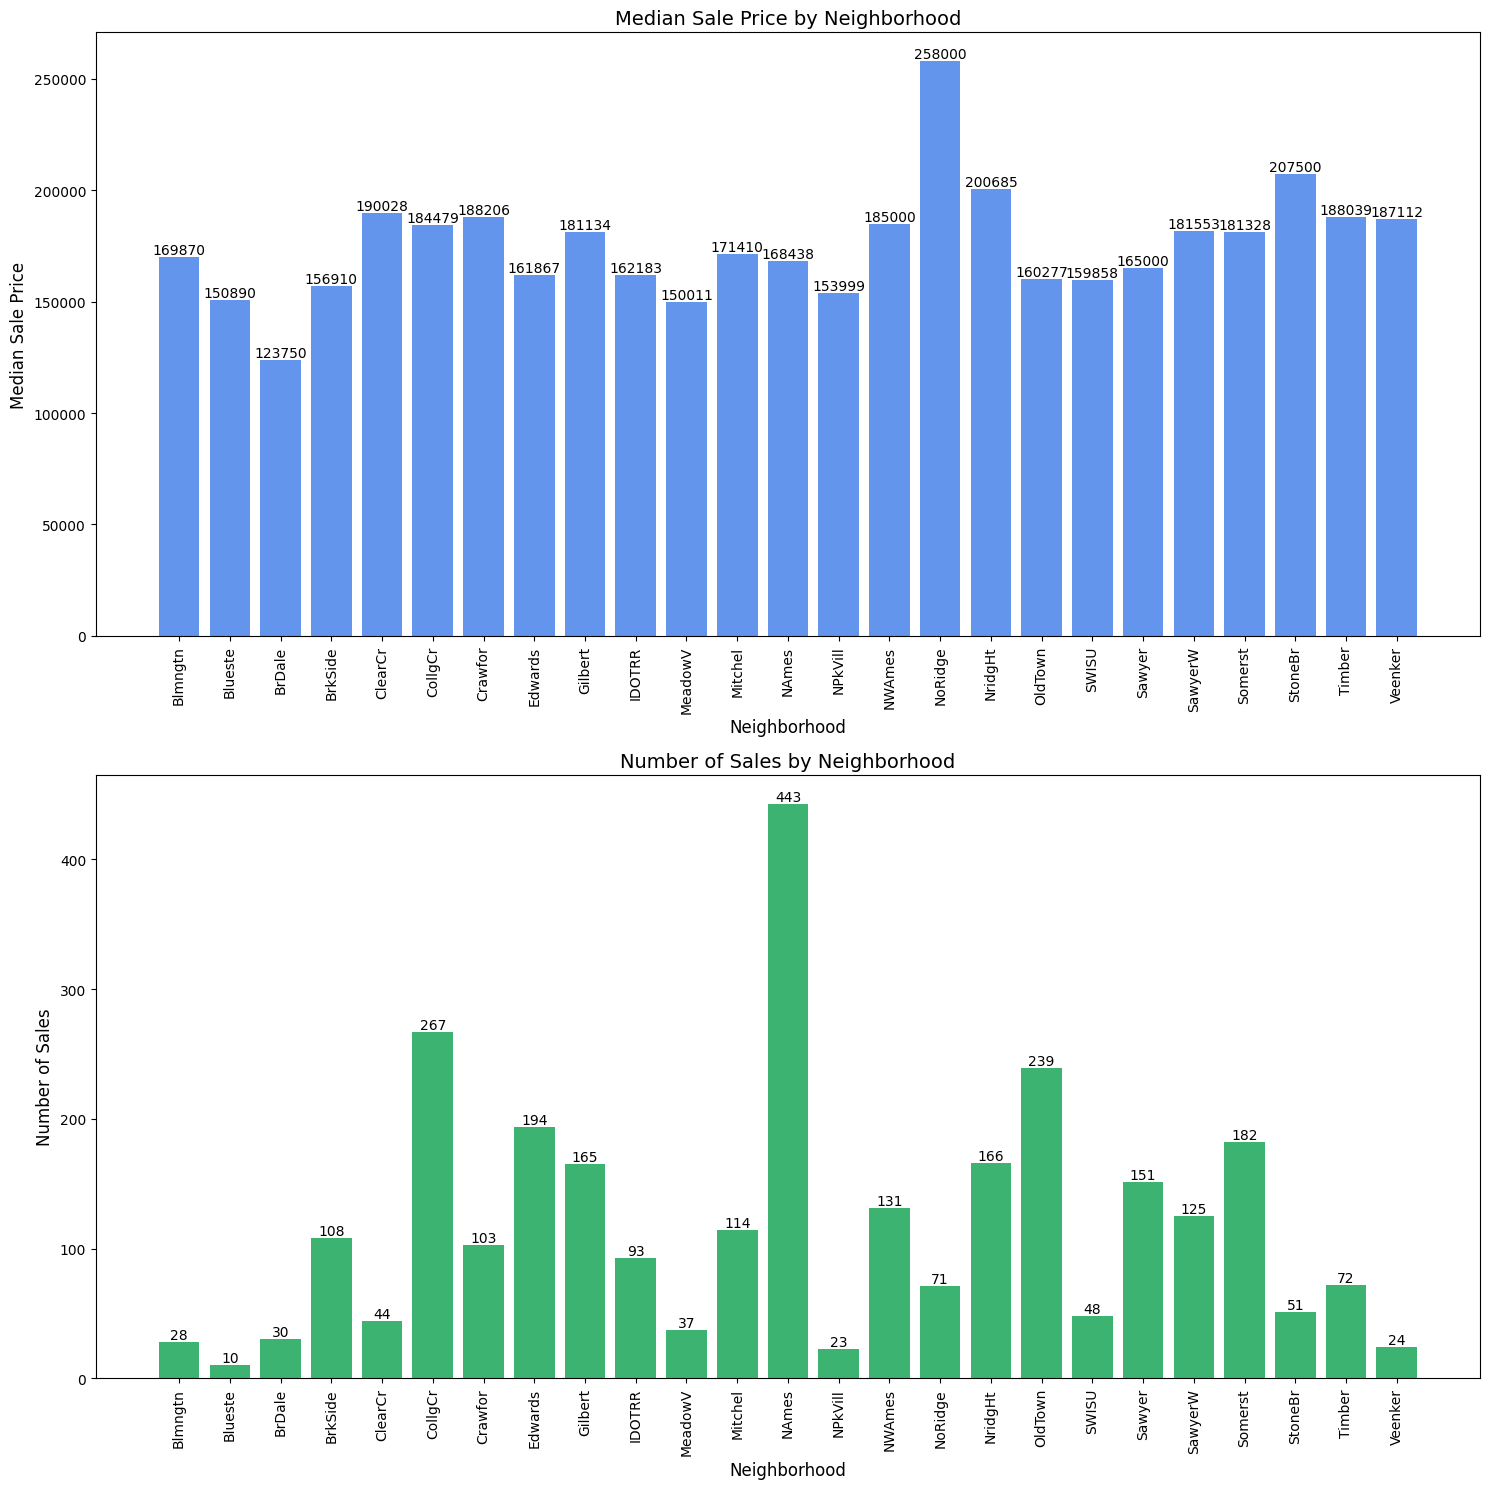

In [ ]:
# Calculate the median SalePrice for each neighborhood
# This helps us understand which neighborhoods tend to have higher property values.
median_sale_price = df_original.groupby('Neighborhood')['SalePrice'].median().reset_index()

# Calculate the number of sales for each neighborhood
# This allows us to see which areas have the most real estate transactions.
sales_count = df_original.groupby('Neighborhood')['SalePrice'].count().reset_index(name='Sales Count')

# Merge the two DataFrames on the Neighborhood column
# This combines both datasets so we can visualize median prices and sales count together.
combined_data = pd.merge(median_sale_price, sales_count, on='Neighborhood')

# Create a combined figure with two subplots (2 rows, 1 column)
fig, axs = plt.subplots(2, 1, figsize=(15, 15))  # Set figure size

# 1. Bar chart: Median Sale Price by Neighborhood
axs[0].bar(combined_data['Neighborhood'], combined_data['SalePrice'], color='#6495ED')  # Blue bars
axs[0].set_title('Median Sale Price by Neighborhood', fontsize=14)
axs[0].set_xlabel('Neighborhood', fontsize=12)
axs[0].set_ylabel('Median Sale Price', fontsize=12)
axs[0].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Add value labels to each bar
for i, v in enumerate(combined_data['SalePrice']):
    axs[0].text(i, v, f'{v:.0f}', ha='center', va='bottom')

# 2. Bar chart: Number of Sales by Neighborhood
axs[1].bar(combined_data['Neighborhood'], combined_data['Sales Count'], color='#3CB371')  # Green bars
axs[1].set_title('Number of Sales by Neighborhood', fontsize=14)
axs[1].set_xlabel('Neighborhood', fontsize=12)
axs[1].set_ylabel('Number of Sales', fontsize=12)
axs[1].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Add value labels to each bar
for i, v in enumerate(combined_data['Sales Count']):
    axs[1].text(i, v, f'{v:.0f}', ha='center', va='bottom')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the combined plots
plt.show()

Bar chart that show the median SalePrice and number of sales by MSSubClass

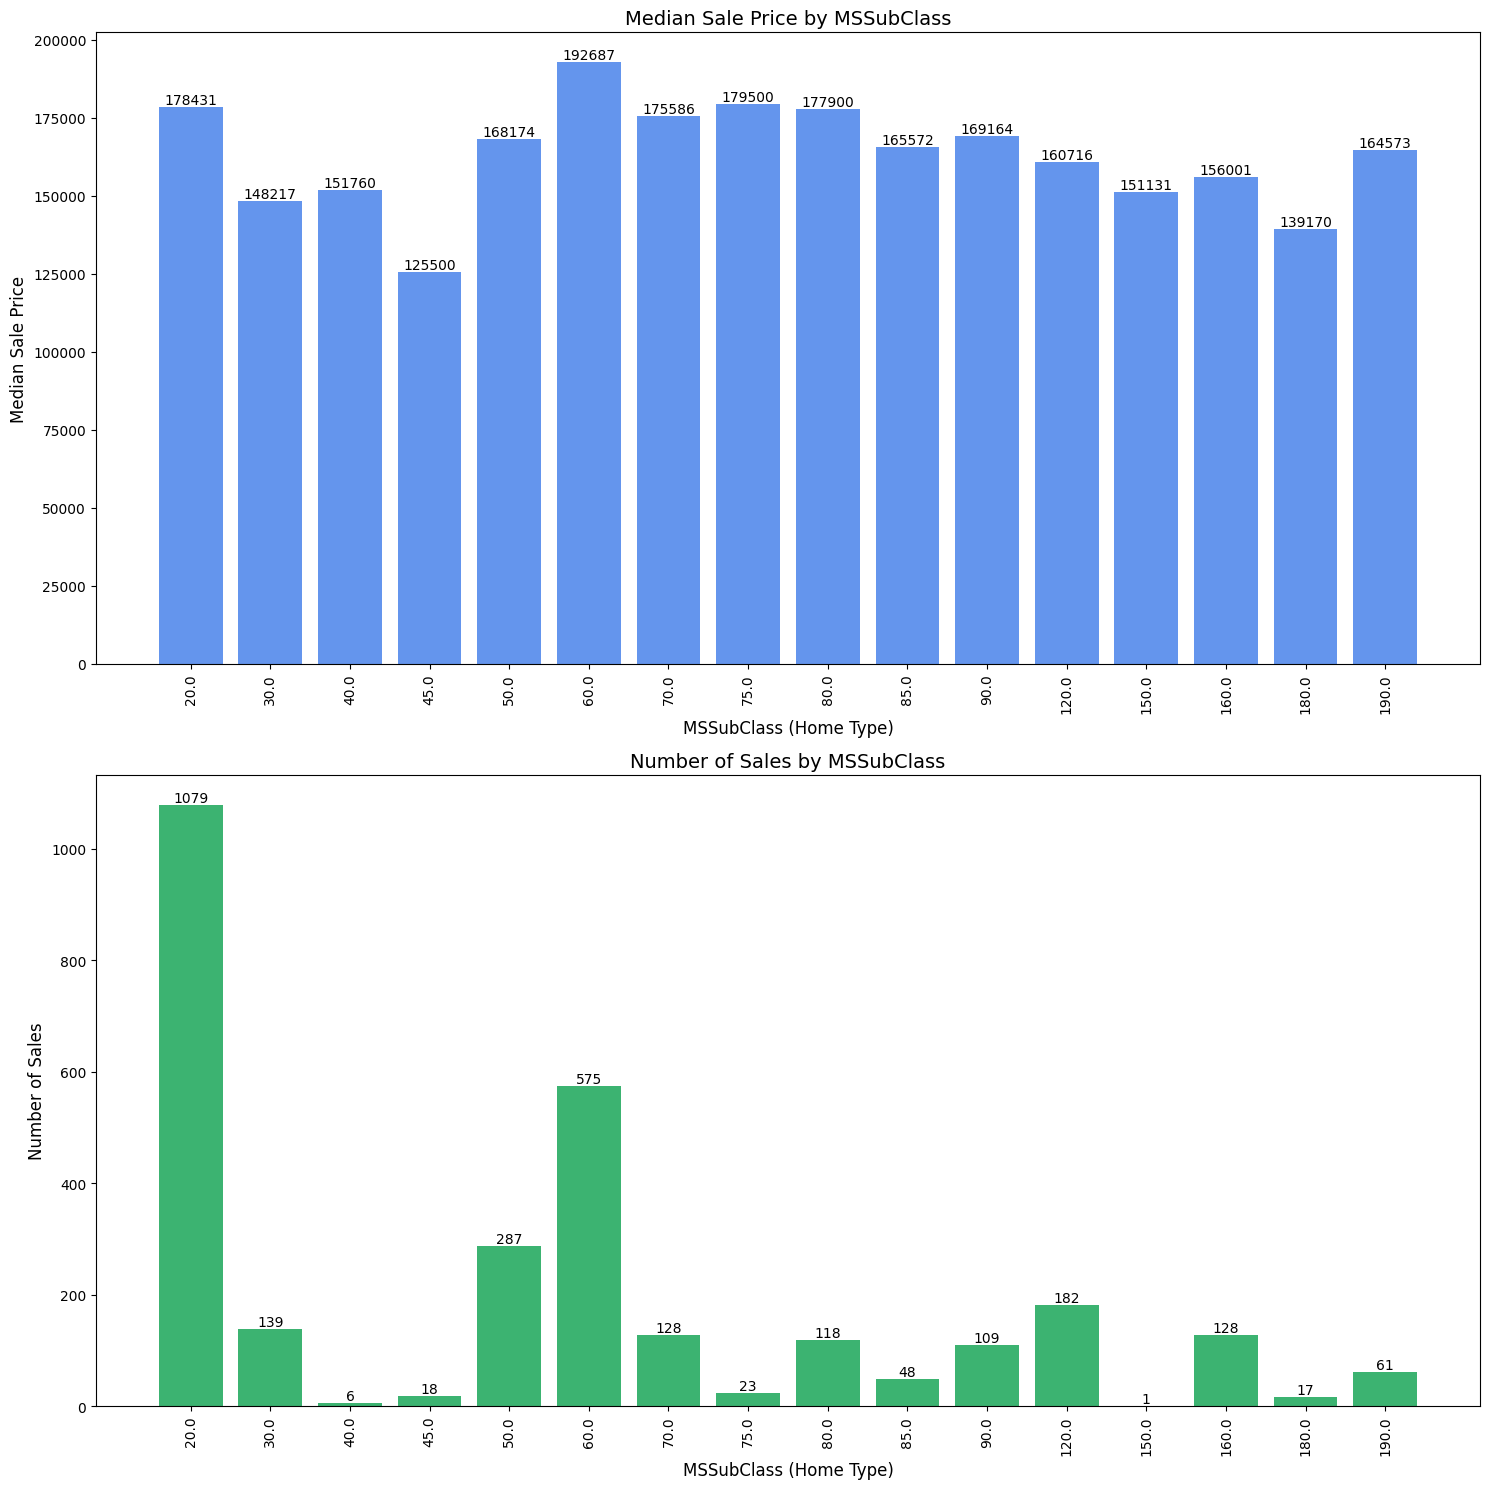

In [ ]:
# Calculate the median SalePrice for each MSSubClass
# MSSubClass represents different types of dwelling styles, so this helps us compare pricing across home types.
median_sale_price = df_original.groupby('MSSubClass')['SalePrice'].median().reset_index()

# Calculate the number of sales for each MSSubClass
# This allows us to see which home styles are most commonly sold.
sales_count = df_original.groupby('MSSubClass')['SalePrice'].count().reset_index(name='Sales Count')

# Merge the two DataFrames on MSSubClass
# This combines both datasets so we can visualize median prices and sales count together.
combined_data = pd.merge(median_sale_price, sales_count, on='MSSubClass')

# Create a combined figure with two subplots (2 rows, 1 column)
fig, axs = plt.subplots(2, 1, figsize=(15, 15))  # Set figure size

# 1. Bar chart: Median Sale Price by MSSubClass
axs[0].bar(combined_data['MSSubClass'].astype(str), combined_data['SalePrice'], color='#6495ED')  # Blue bars
axs[0].set_title('Median Sale Price by MSSubClass', fontsize=14)
axs[0].set_xlabel('MSSubClass (Home Type)', fontsize=12)
axs[0].set_ylabel('Median Sale Price', fontsize=12)
axs[0].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Add value labels to each bar
for i, v in enumerate(combined_data['SalePrice']):
    axs[0].text(i, v, f'{v:.0f}', ha='center', va='bottom')

# 2. Bar chart: Number of Sales by MSSubClass
axs[1].bar(combined_data['MSSubClass'].astype(str), combined_data['Sales Count'], color='#3CB371')  # Green bars
axs[1].set_title('Number of Sales by MSSubClass', fontsize=14)
axs[1].set_xlabel('MSSubClass (Home Type)', fontsize=12)
axs[1].set_ylabel('Number of Sales', fontsize=12)
axs[1].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Add value labels to each bar
for i, v in enumerate(combined_data['Sales Count']):
    axs[1].text(i, v, f'{v:.0f}', ha='center', va='bottom')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the combined plots
plt.show()

# 3. Regression Analysis

# 3.1	Model Selection

Regression of SalePrice on the top 10 most correlated predictors

In [ ]:
# Function: Perform Ordinary Least Squares (OLS) Regression
# This function simplifies the process of fitting a linear regression model and displaying results.

def regress(y, x):
    """
    Runs an OLS regression and prints the model summary.

    Parameters:
    - y: Target variable (dependent variable)
    - x: Predictor variables (independent variables)

    Returns:
    - results: The fitted regression model
    """
    # Define the OLS regression model
    model = sm.OLS(y, x)

    # Fit the model to the data
    results = model.fit()

    # Print the model summary, which includes coefficients, p-values, and R-squared
    print(results.summary())

    # Return the fitted model for further analysis
    return results

In [ ]:
# Extract the names of the top 10 most correlated predictors
# These features are the strongest numerical predictors of SalePrice.
top_10_predictors = top_10_corr.index.tolist()
print("Top 10 Most Correlated Predictors with SalePrice:")
print(top_10_predictors)

# Prepare the predictor variables (X) using the top 10 correlated features
# - `MS(df_final[top_10_predictors]).fit_transform(df)`: Applies model specification transformations
x_top_10_no_drop = MS(df_final[top_10_predictors]).fit_transform(df)

# Set the target variable (Y) as SalePrice
y_top_10_no_drop = df_final['SalePrice']

# Run the regression model on the selected predictors
# This helps us evaluate how well these features explain variations in home prices.
results_top_10_corr = regress(y_top_10_no_drop, x_top_10_no_drop)

Top 10 Most Correlated Predictors with SalePrice:
['GrLivArea', 'OverallQual', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea', '1stFlrSF', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'MasVnrArea']
                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     230.6
Date:                Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                        18:52:56   Log-Likelihood:                -35274.
No. Observations:                2919   AIC:                         7.057e+04
Df Residuals:                    2908   BIC:                         7.064e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   co

Correlation between Predictors

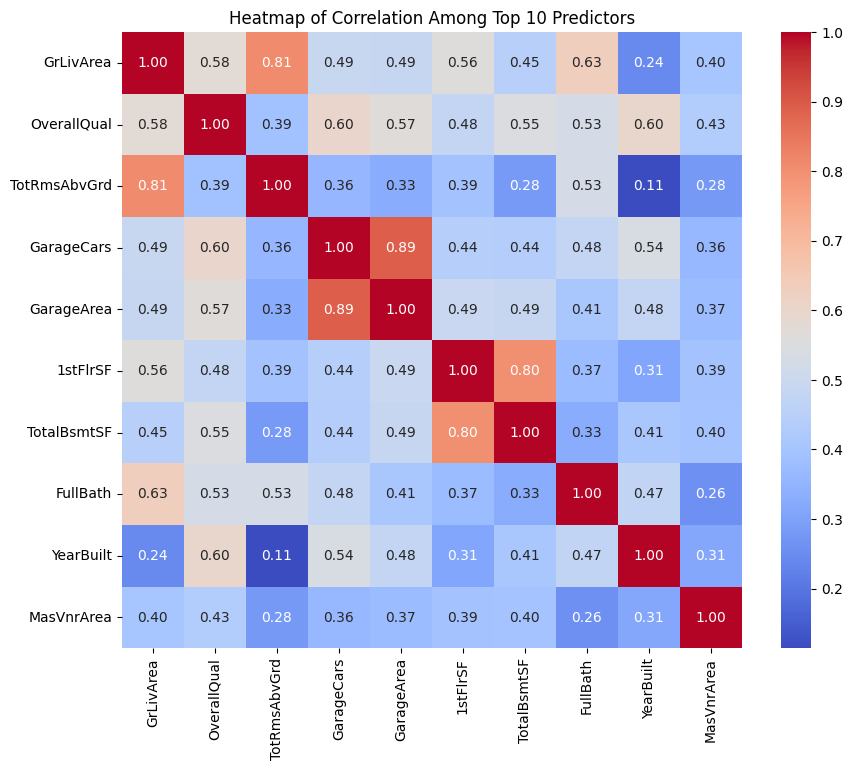

In [ ]:
# Extract the data for the top 10 most correlated predictors
# This allows us to analyze how these features relate to each other.
df_top_10_predictors = df_final[top_10_predictors]

# Compute the correlation matrix for the selected predictors
# This helps us identify multicollinearity among features.
correlation_matrix = df_top_10_predictors.corr()

# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create a heatmap to visualize the correlation matrix
# - `annot=True`: Displays correlation values inside the heatmap
# - `cmap='coolwarm'`: Uses a blue-red gradient for visual contrast
# - `fmt='.2f'`: Formats numbers to 2 decimal places for clarity
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

# Add a title for context
plt.title('Heatmap of Correlation Among Top 10 Predictors')

# Display the heatmap
plt.show()

Drop Predictors

In [ ]:
# Initialize a list to store predictors that will be dropped
# We will remove features that are not statistically significant.
dropped_predictors = []

# Iterate through each predictor in the top 10 list
for col in top_10_predictors:
    # Extract the p-value for the predictor from the regression results
    p_value = results_top_10_corr.pvalues[col]

    # If the p-value is greater than or equal to 0.05, it is not statistically significant
    # We add it to the dropped predictors list
    if p_value >= 0.05:
        dropped_predictors.append(col)

# Display the list of predictors that do not significantly impact SalePrice
print("Predictors dropped due to high p-value (≥ 0.05):")
print(dropped_predictors)

# Create a refined list of predictors by excluding the dropped ones
# These predictors are statistically significant and will be used in the final model.
chosen_predictors = [col for col in top_10_predictors if col not in dropped_predictors]

# Display the final set of predictors selected for the regression model
print("\nFinal set of chosen predictors for regression:")
print(chosen_predictors)

Predictors dropped due to high p-value (≥ 0.05):
['GarageCars', 'GarageArea', '1stFlrSF', 'FullBath']

Final set of chosen predictors for regression:
['GrLivArea', 'OverallQual', 'TotRmsAbvGrd', 'TotalBsmtSF', 'YearBuilt', 'MasVnrArea']


# Model 1

In [ ]:
# Prepare the predictor variables (X) using only statistically significant features
# - `MS(df_final[chosen_predictors]).fit_transform(df_final)`: Applies model specification transformations
x_top_10_significant = MS(df_final[chosen_predictors]).fit_transform(df_final)

# Define the target variable (Y) as SalePrice
y_top_10_significant = df_final['SalePrice']

# Run the regression model using the refined set of predictors
# This model is expected to perform better as it only includes statistically significant variables.
results_model_1 = regress(y_top_10_significant, x_top_10_significant)

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     376.6
Date:                Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                        20:07:47   Log-Likelihood:                -35288.
No. Observations:                2919   AIC:                         7.059e+04
Df Residuals:                    2912   BIC:                         7.063e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept    -3.177e+05   6.45e+04     -4.923   

Regression with all predictors in the dataset

In [ ]:
# Select only numerical and boolean columns for model training
df_num_bool = df_final.select_dtypes(include=['number', 'bool'])

# Extract all predictor variables except 'SalePrice'
# - `df_num_bool.columns.drop('SalePrice')`: Ensures we don't include the target variable as a predictor
all_var = df_num_bool.columns.drop('SalePrice')

# Apply model specification transformations to prepare predictor variables (X)
# This step ensures that categorical dummy variables and numerical features are structured properly.
X_all = MS(all_var).fit_transform(df_final)

# Define the target variable (Y) as SalePrice
y_all = df_final['SalePrice']

# Run the regression model using all available numerical and boolean predictors
# This model allows us to analyze the full feature set and determine overall predictive performance.
results_all_predictors = regress(y_all, X_all)

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     9.361
Date:                Sun, 09 Mar 2025   Prob (F-statistic):          6.49e-287
Time:                        20:07:50   Log-Likelihood:                -34835.
No. Observations:                2919   AIC:                         7.044e+04
Df Residuals:                    2533   BIC:                         7.275e+04
Df Model:                         385                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept                 4.73

# Model 2

In [ ]:
# Extract predictors that are statistically significant (p-value < 0.05)
# - `results_all_predictors.pvalues < 0.05`: Filters out insignificant predictors
# - `.index.tolist()`: Converts the filtered predictors into a list
significant_predictors = results_all_predictors.pvalues[results_all_predictors.pvalues < 0.05].index.tolist()

# Display the final set of statistically significant predictors
print("Significant Predictors Selected for Model 2:")
print(significant_predictors)

Significant Predictors Selected for Model 2:
['LotArea', 'OverallCond', 'BsmtFinSF1', 'TotalBsmtSF', '2ndFlrSF', 'GrLivArea', 'KitchenAbvGr', 'TotRmsAbvGrd', 'PoolArea', 'MiscVal', 'MoSold', 'LotShape_Reg', 'LandSlope_Sev', 'Neighborhood_NoRidge', 'Condition1_Norm', 'Condition2_PosA', 'Condition2_PosN', 'RoofMatl_CompShg', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake', 'RoofMatl_WdShngl', 'Exterior2nd_Other', 'MasVnrType_Stone', 'ExterQual_Gd', 'ExterQual_TA', 'KitchenQual_Fa', 'KitchenQual_Gd', 'KitchenQual_TA', 'FireplaceQu_Gd', 'FireplaceQu_TA', 'PavedDrive_Y', 'PoolQC_Gd', 'MiscFeature_Othr', 'MiscFeature_Shed', 'YearBuilt_1893.0']


In [ ]:
# Re-Running Regression with Statistically Significant Predictors (Model 2)

# Select only the statistically significant predictors identified in the previous step
df_significant = df_final[significant_predictors]

# Apply model specification transformations to structure the predictor variables (X)
# This ensures categorical dummy variables and numerical features are properly formatted.
X_all_significant = MS(df_significant).fit_transform(df_significant)

# Define the target variable (Y) as SalePrice
y_all_significant = df_final['SalePrice']

# Run the regression model using only the statistically significant predictors
# This refined model is expected to improve accuracy by eliminating noise from insignificant variables.
results_all_significant = regress(y_all_significant, X_all_significant)

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     80.04
Date:                Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                        20:08:02   Log-Likelihood:                -35074.
No. Observations:                2919   AIC:                         7.023e+04
Df Residuals:                    2880   BIC:                         7.046e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept            -2.124e+05 

# 3.2. Model Prediction

# Model Train

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split  # For splitting the dataset into training and testing sets
from sklearn.linear_model import LinearRegression  # For building the Linear Regression model
from sklearn.metrics import mean_squared_error, r2_score  # For evaluating model performance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def train_model(X, y, model_name):
    """
    Trains a Linear Regression model, makes predictions, and visualizes the results.

    Parameters:
    - X (DataFrame): Predictor variables
    - y (Series): Target variable (Sale Price)
    - model_name (str): Name of the model for labeling the plots

    Returns:
    - None (Prints predictions and displays a scatter plot of actual vs. predicted values)
    """

    # Split the dataset into training (80%) and testing (20%) sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize the Linear Regression model
    lr_model = LinearRegression()

    # Train the model using the training data
    lr_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lr_model.predict(X_test)

    # Create a DataFrame to display actual vs. predicted values
    predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(f"\n{model_name} Predictions:\n", predictions_df)

    # Visualize actual vs. predicted SalePrice using a scatter plot with a regression line
    plt.figure(figsize=(10, 6))
    sns.regplot(x='Actual', y='Predicted', data=predictions_df, ci=95, line_kws={'color': 'red'})
    plt.xlabel('Actual Sale Price')  # Label for x-axis
    plt.ylabel('Predicted Sale Price')  # Label for y-axis
    plt.title(f'Actual vs. Predicted Sale Price ({model_name})')  # Dynamic title with model name
    plt.grid(True)  # Display grid for better readability
    plt.show()

# Comparison of Model 1 and Model 2 Predictions & Performance (With Scatter Plots)

Model 1:

Model 1 Predictions:
         Actual      Predicted
2437  180097.0  146021.464286
2470  192687.0  202329.595520
2359  158152.0  143029.491296
789   187500.0  203053.792079
1642  172024.0  214445.523400
...        ...            ...
2880  209450.0  169607.071274
2295  195159.0  231769.985497
2222  211492.0  225811.954309
1090   92900.0  115506.563567
542   213250.0  208011.509837

[584 rows x 2 columns]


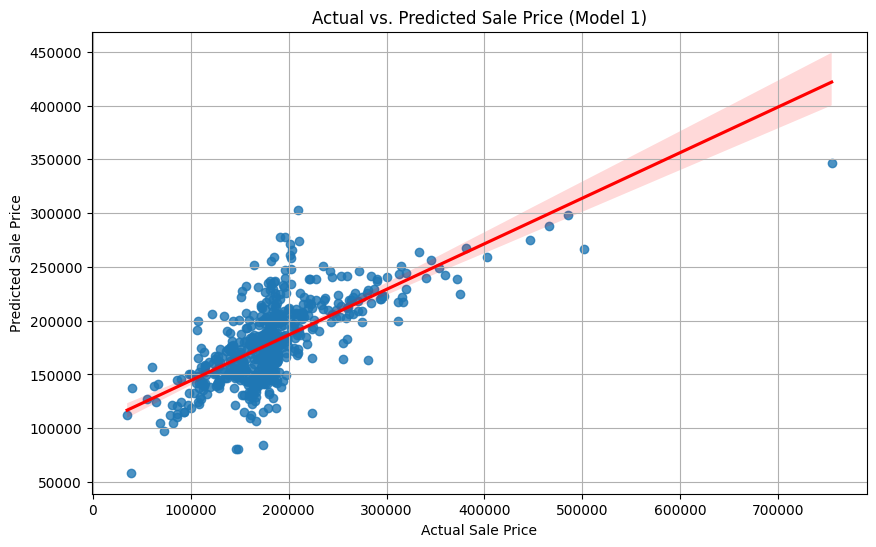


Model 2:

Model 2 Predictions:
         Actual      Predicted
2437  180097.0  156495.717713
2470  192687.0  205780.417502
2359  158152.0  132050.898855
789   187500.0  215455.127661
1642  172024.0  186535.821648
...        ...            ...
2880  209450.0  184492.483748
2295  195159.0  220340.285916
2222  211492.0  238492.209891
1090   92900.0  103186.656793
542   213250.0  196997.703670

[584 rows x 2 columns]


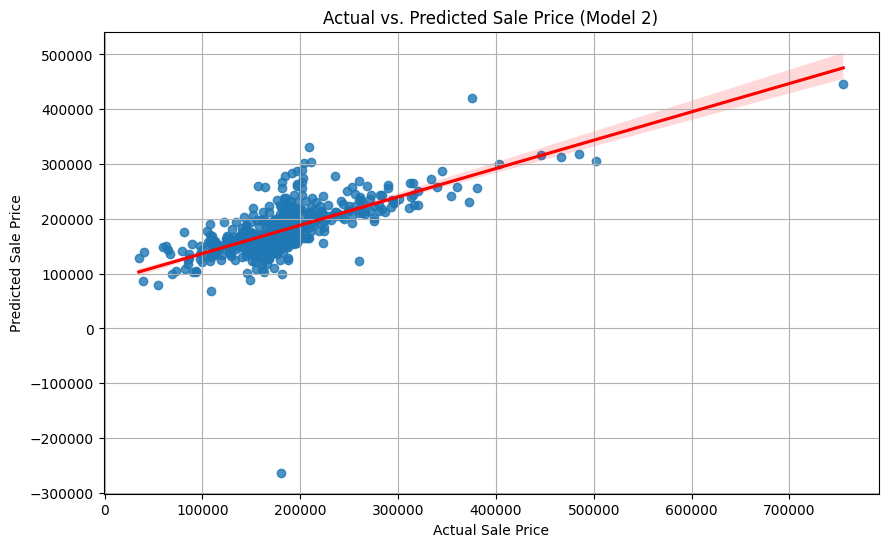

In [ ]:
# Print header to indicate the start of Model 1 training and evaluation
print("Model 1:")
# Train and evaluate the Linear Regression model using the top 10 most correlated predictors
# - `x_top_10_significant`: Features selected based on their high correlation with Sale Price
# - `y_top_10_significant`: Target variable (Sale Price)
train_model(x_top_10_significant, y_top_10_significant, "Model 1")

# Print a newline for better readability in output
print("\nModel 2:")
# Train and evaluate the Linear Regression model using all statistically significant predictors
# - `X_all_significant`: Features selected based on statistical significance (p-value < 0.05)
# - `y_all_significant`: Target variable (Sale Price)
train_model(X_all_significant, y_all_significant, "Model 2")

Calculating Regression Line Slopes for Key Predictors

In [ ]:
# Import necessary libraries
import numpy as np
from sklearn.linear_model import LinearRegression

def calculate_slope(X, y, model_name):
    """
    Trains a Linear Regression model and prints the slope (coefficients) of the regression line.

    Parameters:
    - X (DataFrame): Predictor variables
    - y (Series): Target variable (Sale Price)
    - model_name (str): Name of the model for display purposes

    Returns:
    - None (Prints regression coefficients)
    """

    # Initialize and train the Linear Regression model
    lr_model = LinearRegression()
    lr_model.fit(X, y)

    # Extract slope (coefficients) and intercept
    coefficients = lr_model.coef_  # Array of slope values for each predictor
    intercept = lr_model.intercept_  # Intercept (y-intercept) of the regression line

    # Print the slope (coefficients) for each predictor variable
    print(f"\n {model_name} Regression Coefficients:")

    # Iterate through each predictor and print its corresponding slope
    for feature, coef in zip(X.columns, coefficients):
        print(f"Slope for {feature}: {coef:.4f}")  # Displaying with 4 decimal places

    # Print the intercept value of the regression model
    print(f"Intercept: {intercept:.4f}")

# Calculate and display slopes for Model 1 (Top 10 most significant predictors)
calculate_slope(x_top_10_significant, y_top_10_significant, "Model 1")

# Calculate and display slopes for Model 2 (All statistically significant predictors)
calculate_slope(X_all_significant, y_all_significant, "Model 2")


 Model 1 Regression Coefficients:
Slope for intercept: 0.0000
Slope for GrLivArea: 35.4450
Slope for OverallQual: 7841.9836
Slope for TotRmsAbvGrd: 3041.5347
Slope for TotalBsmtSF: 16.8508
Slope for YearBuilt: 181.6502
Slope for MasVnrArea: 13.1640
Intercept: -317672.4438

 Model 2 Regression Coefficients:
Slope for intercept: 0.0000
Slope for LotArea: 1.2691
Slope for OverallCond: 2203.7177
Slope for BsmtFinSF1: 7.0497
Slope for TotalBsmtSF: 19.6428
Slope for 2ndFlrSF: 6.2964
Slope for GrLivArea: 24.7394
Slope for KitchenAbvGr: -21070.2291
Slope for TotRmsAbvGrd: 4631.9864
Slope for PoolArea: 85.2153
Slope for MiscVal: -8.2194
Slope for MoSold: 879.5605
Slope for LotShape_Reg: -495.2157
Slope for LandSlope_Sev: -64536.3184
Slope for Neighborhood_NoRidge: 31858.5276
Slope for Condition1_Norm: 5787.9803
Slope for Condition2_PosA: -87836.0321
Slope for Condition2_PosN: -83024.5660
Slope for RoofMatl_CompShg: 383384.3521
Slope for RoofMatl_Membran: 485757.1902
Slope for RoofMatl_Metal: 4

Display the Regression Equations

In [ ]:
def calculate_regression_equation(X, y, model_name):
    """
    Trains a Linear Regression model and prints the full regression equation.

    Parameters:
    - X (DataFrame): Predictor variables
    - y (Series): Target variable (Sale Price)
    - model_name (str): Name of the model for display purposes

    Returns:
    - None (Prints the full regression equation)
    """

    # Initialize and train the Linear Regression model
    lr_model = LinearRegression()
    lr_model.fit(X, y)

    # Extract slope (coefficients) and intercept
    coefficients = lr_model.coef_  # Array of slope values for each predictor
    intercept = lr_model.intercept_  # Intercept (y-intercept) of the regression line

    # Start building the regression equation as a string
    equation = f"SalePrice = {intercept:.4f}"  # Start with the intercept

    # Iterate through each predictor and append its corresponding slope to the equation
    for feature, coef in zip(X.columns, coefficients):
        equation += f" + ({coef:.4f} * {feature})"

    # Print the complete regression equation
    print(f"\n {model_name} Regression Equation:\n{equation}")

# Calculate and display the regression equation for Model 1 (Top 10 most significant predictors)
calculate_regression_equation(x_top_10_significant, y_top_10_significant, "Model 1")

# Calculate and display the regression equation for Model 2 (All statistically significant predictors)
calculate_regression_equation(X_all_significant, y_all_significant, "Model 2")


 Model 1 Regression Equation:
SalePrice = -317672.4438 + (0.0000 * intercept) + (35.4450 * GrLivArea) + (7841.9836 * OverallQual) + (3041.5347 * TotRmsAbvGrd) + (16.8508 * TotalBsmtSF) + (181.6502 * YearBuilt) + (13.1640 * MasVnrArea)

 Model 2 Regression Equation:
SalePrice = -212355.9450 + (0.0000 * intercept) + (1.2691 * LotArea) + (2203.7177 * OverallCond) + (7.0497 * BsmtFinSF1) + (19.6428 * TotalBsmtSF) + (6.2964 * 2ndFlrSF) + (24.7394 * GrLivArea) + (-21070.2291 * KitchenAbvGr) + (4631.9864 * TotRmsAbvGrd) + (85.2153 * PoolArea) + (-8.2194 * MiscVal) + (879.5605 * MoSold) + (-495.2157 * LotShape_Reg) + (-64536.3184 * LandSlope_Sev) + (31858.5276 * Neighborhood_NoRidge) + (5787.9803 * Condition1_Norm) + (-87836.0321 * Condition2_PosA) + (-83024.5660 * Condition2_PosN) + (383384.3521 * RoofMatl_CompShg) + (485757.1902 * RoofMatl_Membran) + (463457.6817 * RoofMatl_Metal) + (332111.4242 * RoofMatl_Roll) + (389015.2881 * RoofMatl_Tar&Grv) + (392876.3222 * RoofMatl_WdShake) + (486445

# 4. Be creative!

In [ ]:
# Import necessary libraries for data processing, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load the dataset from Google Drive
file_path = '/content/drive/My Drive/BUS 310: Business Analytics III/Group Assignment 1/housing_price_full_sample.csv'
df = pd.read_csv(file_path)

# Restore original 'MoSold' if it was converted into dummy variables
# - If 'MoSold' is missing, recreate it by finding the highest probability month from dummy variables
if "MoSold" not in df.columns:
    mo_sold_cols = [col for col in df.columns if col.startswith("MoSold_")]
    if mo_sold_cols:
        df["MoSold"] = df[mo_sold_cols].idxmax(axis=1).str.replace("MoSold_", "").astype(int)

# Create a new feature: House Age
# - This feature helps us analyze how the age of a house impacts its price.
# - We calculate it as the difference between the year the house was sold and the year it was built.
df["House_Age"] = df["YrSold"] - df["YearBuilt"]

# 4.1. Price per Square Foot vs. Neighborhood

<ipython-input-88-6383a3b28a2e>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Neighborhood", y="Price_per_sqft", data=df, palette="coolwarm")  # Box plot with color gradient


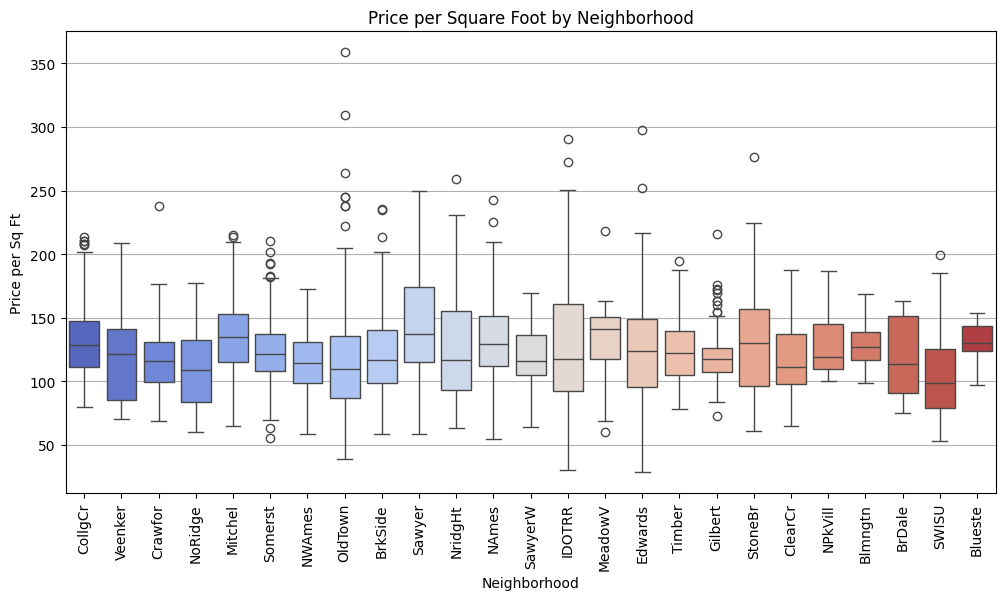

In [ ]:
# Create a new feature: Price per Square Foot
# - This metric helps compare home values across neighborhoods more effectively.
# - It is calculated as SalePrice divided by GrLivArea (above-ground living area).
df["Price_per_sqft"] = df["SalePrice"] / df["GrLivArea"]

# Create a box plot to visualize price per square foot across different neighborhoods
plt.figure(figsize=(12, 6))  # Set figure size for better readability
sns.boxplot(x="Neighborhood", y="Price_per_sqft", data=df, palette="coolwarm")  # Box plot with color gradient

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=90)

# Add title and axis labels
plt.title("Price per Square Foot by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Price per Sq Ft")

# Add gridlines for better readability
plt.grid(axis="y")

# Display the plot
plt.show()

# 4.2. Outlier Detection - SalePrice vs. GrLivArea

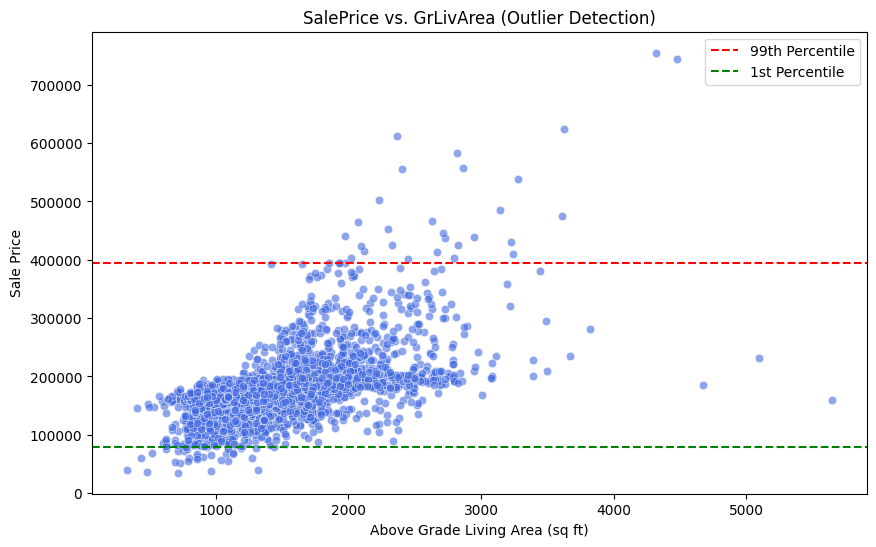

In [ ]:
# Create a scatter plot to analyze the relationship between SalePrice and GrLivArea
# - This helps detect outliers and unusual trends in house pricing.

plt.figure(figsize=(10, 6))  # Set figure size for better visualization
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"], alpha=0.6, color="royalblue")  # Scatter plot

# Add horizontal dashed lines to highlight extreme outliers
# - The 99th percentile marks the upper extreme, indicating luxury or overpriced homes.
# - The 1st percentile marks the lower extreme, indicating possible underpricing or poor conditions.
plt.axhline(df["SalePrice"].quantile(0.99), color="red", linestyle="dashed", label="99th Percentile")
plt.axhline(df["SalePrice"].quantile(0.01), color="green", linestyle="dashed", label="1st Percentile")

# Add title and axis labels for better clarity
plt.title("SalePrice vs. GrLivArea (Outlier Detection)")
plt.xlabel("Above Grade Living Area (sq ft)")
plt.ylabel("Sale Price")

# Add a legend to explain the percentile lines
plt.legend()

# Display the plot
plt.show()

# 4.3. House Age Impact on Sale Price

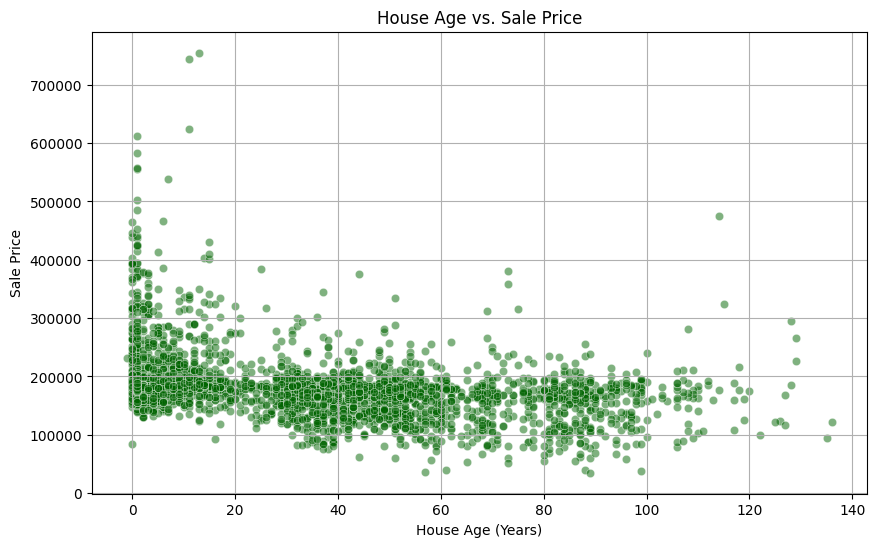

In [ ]:
# Create a scatter plot to analyze the relationship between House Age and Sale Price
# - This helps us understand whether older homes tend to have higher or lower values.

plt.figure(figsize=(10, 6))  # Set figure size for better visualization
sns.scatterplot(x=df["House_Age"], y=df["SalePrice"], alpha=0.5, color="darkgreen")  # Scatter plot

# Add title and axis labels for clarity
plt.title("House Age vs. Sale Price")
plt.xlabel("House Age (Years)")
plt.ylabel("Sale Price")

# Add grid lines to improve readability
plt.grid()

# Display the plot
plt.show()

# 4.4. Residual Plot - Checking Model Fit

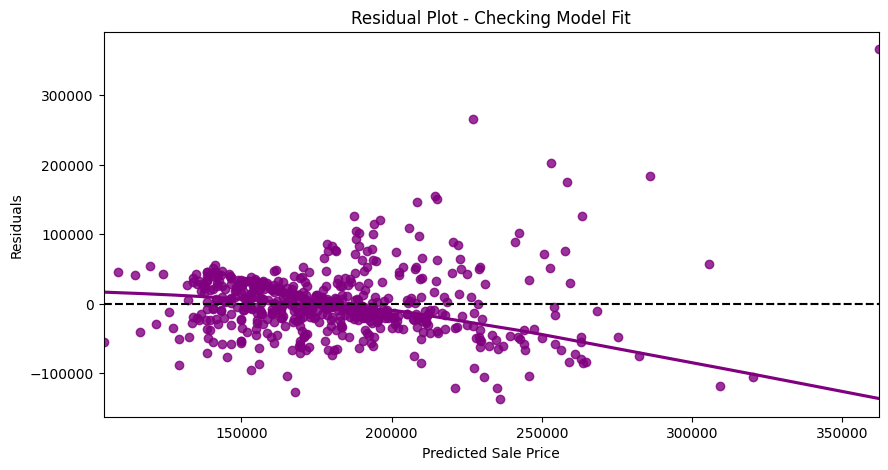

In [ ]:
# Selecting GrLivArea as the predictor for simplicity
# - This model uses only one predictor (above-grade living area) to estimate SalePrice.
X = df[["GrLivArea"]]
y = df["SalePrice"]

# Split the data into training and testing sets
# - 80% training, 20% testing
# - random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit a simple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Calculate residuals (difference between actual and predicted SalePrice)
residuals = y_test - y_pred

# Create a residual plot to check for patterns in prediction errors
plt.figure(figsize=(10, 5))
sns.residplot(x=y_pred, y=residuals, lowess=True, color="purple")  # Residual plot with a smoothing line

# Add a horizontal reference line at zero
plt.axhline(0, color="black", linestyle="dashed")

# Add title and axis labels
plt.title("Residual Plot - Checking Model Fit")
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

# Display the plot
plt.show()

# 4.5. Feature Importance using Random Forest

<ipython-input-93-e8706263267f>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")  # Color-coded bar chart


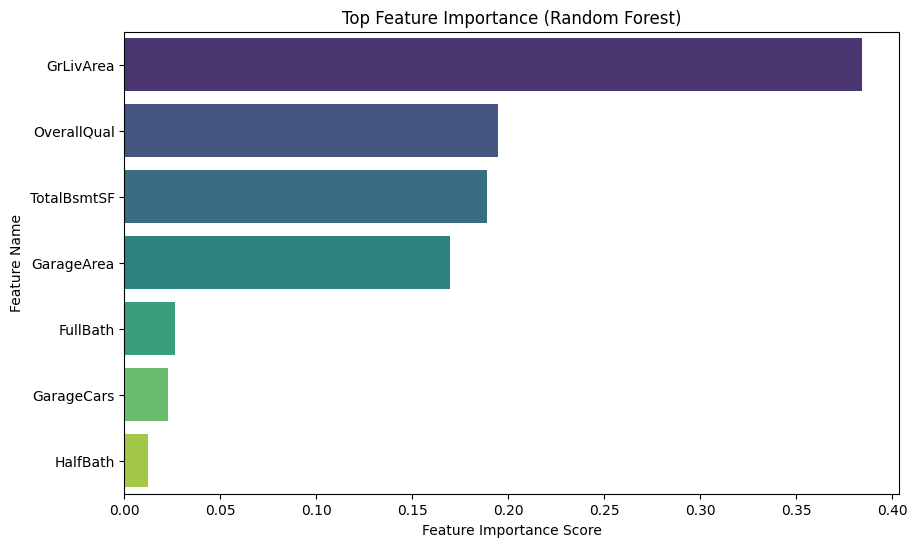

In [ ]:
# Selecting key numerical features for importance ranking
# - These features are commonly strong predictors of SalePrice.
numerical_features = ["GrLivArea", "OverallQual", "TotalBsmtSF", "GarageCars", "GarageArea", "FullBath", "HalfBath"]

# Initialize and train a Random Forest model
# - n_estimators=100: Uses 100 decision trees for better accuracy.
# - random_state=42: Ensures reproducibility of results.
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(df[numerical_features], df["SalePrice"])  # Train model on selected features

# Calculate feature importance scores
# - The higher the score, the more influential the feature is in predicting SalePrice.
feature_importances = pd.Series(rf.feature_importances_, index=numerical_features).sort_values(ascending=False)

# Plot the feature importance scores as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")  # Color-coded bar chart

# Add title and axis labels
plt.title("Top Feature Importance (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Name")

# Display the plot
plt.show()